In [1]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import math
import re

import sys
# sys.path.append('../../../')
# from mount_drive import mount_s_drive

In [2]:
import pandas as pd
import os
import sys
dir1 = os.path.abspath(os.path.join(os.getcwd(), '../../analysisFunctions'))
# dir2 = os.path.abspath(os.path.join(os.getcwd(), '../GANITE'))
sys.path.insert(0, dir1)
# sys.path.insert(0, dir2)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.feature_selection import VarianceThreshold
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, roc_auc_score, make_scorer, auc, roc_curve
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from xgboost import XGBClassifier, XGBRegressor, plot_tree, plot_importance, to_graphviz
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from graphviz import Source
from sklearn import tree
from sklearn.svm import SVC, LinearSVC, SVR
import re
from machine_learning import *
# from hyperion_utils import *
# from bartpy.sklearnmodel import SklearnModel
# import doubleml as dml
# import pymc as pm
# import pymc_bart as pmb
from sklearn.neighbors import KNeighborsRegressor
# from pybart.api import BART
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2
# from econml.dml import CausalForestDML
# import causalpy as cp
# import pymc_bart as pmb
from sklearn.cluster import KMeans,AgglomerativeClustering, SpectralClustering, MeanShift, DBSCAN 
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
import random
from stepmix.stepmix import StepMix
from sklearn.metrics import silhouette_score
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from PMAPUtil import *

In [24]:
columns = [
    # Demographics
    "gender",
    "age",

    # Neurologic
    "first_mGCS",
    "flo_first_r_cpn_glasgow_coma_scale_score",

    # Vital Signs – First
    "flo_first_bp_systolic",
    "flo_first_bp_diastolic",
    "flo_first_r_map",
    "flo_first_temperature",
    "flo_first_r_ed_pre-arrival_pulse_(heart_rate)",
    "flo_first_r_fio2",
    "flo_first_r_spo2:fio2_covid-19_calculation",

    # Severity Scores
    "flo_first_r_sofa_score",

    "flo_first_r_jhm_ip_sofa_cv_score",
    "flo_first_r_jhm_ip_sofa_cns_score",
    "flo_first_r_jhm_ip_sofa_coagulation_score",
    "flo_first_r_jhm_ip_sofa_liver_score",
    "flo_first_r_jhm_ip_sofa_renal_score",
    
    # Respiratory / Oxygenation
    "flo_first_r_jhm_ip_pao2/fio2",
    "flo_first_r_jhm_ip_rt_vent_fio2_(%)",
    "flo_first_r_jhm_ip_rt_conv._vent._high_respiratory_rate",
    "flo_first_r_jhm_ip_rt_conv._vent._low_respiratory_rate",

    # Hemodynamics / Shock
    "flo_first_r_norepinephrine_volume",

    # Renal / Urine Output
    "flo_first_jhm_ip_4hr_urine_output_goal_(12ml/kg)_is_at_least",
    "flo_first_jhm_ip_4hr_urine_output_goal_(2ml/kg)_is_at_least",

    # Anthropometrics
    "flo_first_r_bmi",

    # Labs – First
    "lab_first_troponin",
    "lab_first_creatinine,whole_blood",
    "lab_first_lactate",
    "lab_first_glucose,whole_blood",
    "lab_first_potassium,whole_blood",
    "lab_first_sodium,whole_blood",
    "lab_first_hemoglobin,total,whole_blood",
    "lab_first_aptt",

    'hypothermia',
     'asystole',
     'pea',
     'cardiopulmonary arrest w/ resuscitation',
     'VF'
]
columns = ['lab_first_platelet_function_test',
 'flo_r_ed_vitals_assessment_timer_Mental Status Change',
 'flo_r_ed_vitals_assessment_timer_bicarb givent',
 'flo_r_an_red_screen_monitor_Calcium and bicarb given IV',
 'lab_first_calcium,_serum',
 'lab_first_calcium,_ionized,_whole_blood',
 'lab_first_creatine_kinase_(ck)',
 'lab_first_sun/creatinine_ratio',
 'lab_first_d-dimer,_quantitative',
 'lab_first_vitamin_d_(25-hydroxy)_total',
 'flo_first_r_fio2',
 'flo_first_r_an_fio2',
 'lab_first_glucose,_blood-_poc',
 'lab_first_glucose,_pleural_fluid',
 'lab_first_hemoglobin',
 'lab_first_hemoglobin_a1c',
 'lab_first_poct_epoc_lactate',
 'lab_first_poct_istat_lactate',
 'flo_first_r_blood_glucose_meter',
 'lab_first_complete_blood_count_(cbc)_+_auto_diff',
 'lab_first_lipase',
 'flo_first_r_jhm_passes',
 'lab_first_magnesium',
 'lab_first_ige,_serum',
 'flo_first_r_paco2',
 'flo_first_r_pao2',
 'flo_first_r_pao2',
 'flo_first_r_paco2',
 'flo_first_r_resp_ph',
 'lab_first_ph,_pleural_fluid',
 'lab_first_platelet_count',
 'lab_first_platelet_(citrate)_count',
 'lab_first_potassium',
 'lab_first_tryptase',
 'lab_first_total_protein_(body_fluid)',
 'lab_first_protein,_peritoneal_fluid',
 'lab_first_sodium',
 'lab_first_sodium,whole_blood',
 'flo_first_r_perf_venous_temp',
 'flo_first_r_cv_mac_blood_temp',
 'lab_first_prothrombin_time_+_inr',
 'lab_first_prothrombin_time,superstat',
 'lab_first_troponin',
 'lab_first_stroke_troponin',
 'flo_first_r_pao2',
 'flo_first_r_sao2',
 'lab_first_troponin',
 'lab_first_stroke_troponin',
 'flo_first_r_jh_blood_units_for_calculation',
 'flo_first_r_ip_blood_administration_volume',
 'flo_first_r_cerebral_perfusion_pressure',
 'flo_first_r_jhm_perf_cerebral_perfusion_temp',
 'flo_r_ip_fall_risk_category_Pos',
 'flo_r_ip_fall_risk_category_Voice',
 'death_at_disch',
 'flo_r_an_red_screen_monitor_Asytole - Brady at 30- Asystole - PEA - Asystole',
 'flo_r_jhm_ip_rt_observed_i:e_DC med31 - 229102',
 'death_at_disch',
 'flo_first_r_ecg_lead2_st',
 'flo_first_r_ecg_lead1_st',
 'flo_r_ed_ecg_proc_md_name_0-No mobility issues',
 'flo_r_ed_ecg_proc_md_name_Gabor Kelen',
 'flo_first_r_neck_2nd_degree_burn',
 'flo_first_r_head_3rd_degree_burn',
 'flo_first_emesis',
 'lab_first_ferritin',
 'lab_first_ferritin',
 'flo_first_emesis',
 'flo_first_r_right_buttock_3rd_degree_burn',
 'flo_r_jhm_ed_ambulance_run_Right brachial',
 'flo_first_r_left_buttock_2nd_degree_burn',
 'flo_r_ed_vitals_assessment_timer_Heart block',
 'flo_r_ed_ecg_proc_md_name_Tan',
 'flo_first_r_ecg_lead3_st',
 'flo_r_ed_ecg_proc_md_name_Flushed',
 'flo_first_r_ecg_lead1_st',
 'flo_first_*old_r_jhm_ip_qtc_interval',
 'flo_first_r_jhm_ip_qtc_ainterval_(sec)',
 'flo_r_ed_ecg_proc_md_name_Tara RN',
 'flo_r_ed_ecg_proc_md_name_Continuously',
 'flo_first_r_resp_vt_set/target_ml',
 'flo_first_r_rt_vt_vent_spontaneous',
 'flo_first_r_ecg_lead3_st',
 'flo_first_r_ecg_lead1_st',
 'flo_first_r_ecg_lead3_st',
 'flo_first_r_ecg_lead2_st',
 'flo_jhm_ip_cuff_pressure_string_Tachycardia',
 'flo_r_ed_ecg_proc_md_name_Tammy Waldman ',
 'flo_r_ed_vitals_assessment_timer_Critical',
 'flo_first_anesthesia_temperature',
 'traumatic cardiac arrest',
 'death due to cardiac arrest',
 'flo_r_ed_vitals_assessment_timer_Original surgical dressing intact',
 'flo_r_jhh_ed_dispo_recommendation_text_cardiac surgery at bedside',
 'med_sodium_chloride_bolus',
 'flo_r_jhh_ed_dispo_recommendation_text_Pt with history of seizure and on suboxaone',
 'flo_first_bp_diastolic',
 'med_lidocaine',
 'flo_r_ed_pre-hospital_ekg_no cardiac activity on bedside echo',
 'flo_r_jhh_ed_dispo_supplemental_info_no cardiac motion on bedside echo',
 'flo_first_emesis',
 'ed_visit_yn',
 'flo_first_r_jhm_ip_sofa_renal_score',
 'lab_first_renal_function_panel',
 'lab_first_hemoglobin',
 'lab_first_hemoglobin_a1c',
 'flo_first_r_jhm_ip_cerebral_oximetry_right',
 'flo_first_r_cerebral_perfusion_pressure',
 'flo_first_r_pulmonary_vasclar_resistance_calc',
 'flo_first_r_pulmonary_capillary_wedge_pressure',
 'med_sodium_bicarbonate_infusion',
 'flo_first_intravenous_intake',
 'med_epinephrine_1_mg/ml',
 'med_epinephrine_0.1_mg/ml_injection_syringe',
 'med_epinephrine_1_mg/ml',
 'med_epinephrine_hcl_2_mg/100_ml',
 'med_epinephrine_0.1_mg/ml_injection_syringe',
 'med_epinephrine_infusion_4_mcg/ml_in_250_ml_d5w',
 'age',
 'flo_r_ed_jhh_plan_of_care_notes_Age > 65',
 'lab_first_platelet_(citrate)_count',
 'lab_first_platelet_function_test',
 'flo_first_r_dobutamine_volume',
 'flo_first_r_vasopressin_volume',
 'med_ondansetron_hcl',
 'death_at_disch',
 'flo_first_r_systemic_vascular_resistance_calc',
 'flo_r_jhm_ip_rt_observed_i:e_central line and arterial line to be placed per Dr. Risko. ',
 'flo_jhm_ip_cust_formula_fall_risk_0-No fall history w/in 6 months prior to admission',
 'flo_r_jhm_trews_session_manual_override_History of DM',
 'flo_r_ed_vitals_assessment_timer_bicarb givent',
 'flo_r_ip_rt_jhm_conv._vent_high_tv_plan for Ca, mag, bicarb, amio ',
 'flo_r_ed_vitals_assessment_timer_bicarb givent',
 'med_sodium_bicarbonate_8.4_%',
 'flo_first_r_bmi',
 'flo_first_haz_r_bmi_osa_screen',
 'cardiopulmonary arrest',
 'cardiopulmonary arrest w/ resuscitation',
 'traumatic cardiac arrest',
 'death due to cardiac arrest',
 'med_heparin',
 'lab_first_haptoglobin',
 'med_heparin',
 'flo_r_jhm_trews_version_1#',
 'med_heparin',
 'flo_r_jhm_trews_version_105',
 'med_heparin',
 'flo_r_jhm_trews_version_11',
 'med_heparin',
 'med_chlorhexidine_gluconate_0.12%',
 'med_heparin',
 'flo_r_jhm_trews_version_1:1.3',
 'med_heparin',
 'flo_r_ed_care_handoff_rn_14',
 'med_heparin',
 'flo_r_cam-icu_overall_Positional',
 'med_heparin',
 'flo_r_cam-icu_overall_Positional',
 'med_heparin',
 'lab_first_haptoglobin',
 'med_heparin',
 'lab_first_haptoglobin',
 'med_heparin',
 'flo_r_cam-icu_overall_Positional',
 'med_heparin',
 'flo_r_cam-icu_overall_Positional',
 'med_heparin',
 'flo_r_cam-icu_overall_Positional',
 'med_heparin',
 'flo_r_cam-icu_overall_Positional',
 'lab_first_ck_mb_reflex',
 'lab_first_urinalysis_with_reflex_culture',
 'lab_first_coagulation_screen',
 'flo_first_r_jhm_ip_sofa_coagulation_score',
 'flo_first_r_amiodarone_volume',
 'med_amiodarone_360_mg/200_ml',
 'flo_first_r_amiodarone_volume',
 'med_amiodarone_150_mg/100_ml',
 'lab_first_ck_mb_reflex',
 'lab_first_urinalysis_with_reflex_culture',
 'flo_r_provider_name_ Adult Neurosurgery - Low Risk',
 'flo_jhm_r_ed_electronic_triage_supplement_Low Risk - Paralysis/Completely Immobilized',
 'med_lidocaine',
 'med_famotidine',
 'med_lidocaine',
 'med_famotidine',
 'flo_r_an_red_screen_monitor_Atrial fibrillation',
 'flo_r_jhm_ip_rt_mech_vent_id_#_provider doing bedsaide ultrasound',
 'flo_r_an_red_screen_monitor_Atrial fibrillation',
 'flo_r_jhm_ip_rt_mech_vent_id_#_provider doing bedsaide ultrasound',
 'flo_first_pulse_ox_heart_rate',
 'flo_first_r_amb_fcc_assess',
 'flo_first_r_fio2',
 'flo_first_r_an_fio2',
 'flo_first_r_jhm_ip_rt_conv._vent._low_respiratory_rate',
 'flo_first_r_jhm_ip_rt_conv._vent._high_respiratory_rate',
 'flo_first_r_cpn_glasgow_coma_scale_score',
 'flo_first_r_cpn_glasgow_coma_scale_score_2',
 'flo_first_r_cpn_glasgow_coma_scale_score',
 'flo_first_r_cpn_glasgow_coma_scale_score_2',
 'flo_r_ed_jhh_plan_of_care_notes_Hypertension',
 'hypothermia',
 'hypothermia',
 'med_heparin',
 'flo_first_r_jhm_ip_sofa_liver_score',
 'flo_first_r_morse_fall_risk_score',
 'flo_first_r_jhm_ip_crrt_circuit_volume',
 'flo_first_r_l_thigh_circumference_(cm)',
 'flo_first_r_apache_temperature',
 'med_ondansetron_hcl',
 'cardiac arrest with successful resuscitation',
 'traumatic cardiac arrest',
 'flo_first_r_perf_gas_flow',
 'flo_first_r_ip_vent_flow_vcac',
 'flo_first_r_jhm_ad_masa_score',
 'flo_first_r_jhm_ip_icu_cards_scale_score',
 'med_morphine_10_mg/ml_soln_erx_5168',
 'med_morphine_10_mg/ml_injection_syringe',
 'flo_first_r_jhm_ip_impella_motor_current_mean',
 'flo_first_r_jhm_ip_impella_left_motor_current_mean',
 'death due to cardiac arrest',
 'traumatic cardiac arrest',
 'flo_first_r_an_agents_n2o_flow',
 'flo_first_r_jhm_an_perf_perfusion_flow',
 'med_norepinephrine_infusion_8_mg_/_250_ml_ns',
 'med_norepinephrine_infusion_16_mg_/_116_ml_ns',
 'flo_first_r_amb_fcc_assess',
 'flo_first_r_amb_fcc_total_time',
 'flo_first_r_fio2',
 'flo_first_r_sao2',
 'flo_r_jhm_trews_version_Irregular',
 'flo_r_jhm_ed_ambulance_run_49',
 'lab_first_lipase',
 'flo_r_jhm_trews_session_end_dtm_Zoll pads on pt.',
 'flo_first_r_lorazepam_volume',
 'med_lorazepam_2_mg/ml_injection_syringe',
 'flo_first_r_jhm_passes',
 'flo_r_jhm_rcp_time_Passive',
 'lab_first_pro-b_natriuretic_peptide',
 'lab_first_b-type_natriuretic_peptide',
 'flo_first_weight/scale',
 'flo_first_r_jhm_ip_weight_kg',
 'flo_first_r_pulmonary_vasclar_resistance_calc',
 'flo_first_r_pulmonary_capillary_wedge_pressure',
 'flo_first_r_ad_right_pupil_npi',
 'flo_first_r_ad_left_pupil_npi',
 'flo_first_r_total_burn_area',
 'lab_first_c-reactive_protein',
 'flo_first_r_ad_left_pupil_npi',
 'flo_first_*old_r_pupil_size_(mm)_left',
 'flo_first_r_total_burn_area',
 'lab_first_hiv1_rna_realtime_pcr',
 'traumatic cardiac arrest',
 'flo_first_r_cardiac_index',
 'lab_first_ck_mb_reflex',
 'lab_first_urinalysis_with_reflex_culture',
 'lab_first_ck_mb_reflex',
 'lab_first_urinalysis_with_reflex_culture',
 'traumatic cardiac arrest',
 'death due to cardiac arrest',
 'flo_first_*old_r_ed_sedation_narr_qt_interval',
 'lab_first_sedimentation_rate',
 'last_mGCS_time',
 'flo_first_pulse',
 'flo_first_r_an_spo2',
 'flo_first_r_cv_mac_spo2',
 'lab_first_hemoglobin_a1c',
 'flo_first_r_skin_braden_scale_score',
 'flo_first_height',
 'med_heparin',
 'flo_r_jhm_ed_dispo_acute_risk_cardiac arrest',
 'flo_r_jhm_trews_version_Incoming cardiac arrest',
 'flo_r_jhm_ed_dispo_acute_risk_cardiac arrest',
 'flo_r_jhm_ed_dispo_crit_risk_Pt arrived. Unwitnessed arrest, pt paraplegic, recent RLE surgery, heroin abuse',
 'flo_first_r_jhm_ip_temp_goal',
 'flo_first_r_jhm_ip_temp_goal_2',
 'flo_r_jhh_ip_rt_low_etco2_alarm_Verbal',
 'flo_r_ed_vitals_assessment_timer_Unable to return demo and/or verbal instructions',
 'flo_first_r_ip_vent_vt_low',
 'flo_first_r_ip_vent_vt_high',
 'osler_id',
 'asystole',
 'cardiopulmonary arrest',
 'cardiopulmonary arrest w/ resuscitation',
 'flo_first_r_sofa_score',
 'flo_first_r_jhm_ip_sofa_coagulation_score',
 'flo_first_r_jhm_ip_sofa_liver_score',
 'lab_first_hepatic_function_panel',
 'flo_r_provider_name_ Adult Neurosurgery - Low Risk',
 'flo_r_jhm_ed_fall_risk_custom_formula_Patient has stopped bleeding @ this time. Plan to have 6.0 cuffed tube placed. Neuro IR paged',
 'flo_first_r_jhm_ip_sofa_renal_score',
 'lab_first_renal_function_panel',
 'flo_first_r_jhm_ip_sofa_resp_score',
 'flo_first_r_sofa_score',
 'flo_first_r_sofa_score',
 'flo_first_r_jhm_ip_sofa_cv_score',
 'flo_first_r_sofa_score',
 'flo_first_r_jhm_ip_sofa_cv_score',
 'flo_first_r_sofa_score',
 'flo_first_r_jhm_ip_sofa_cv_score',
 'flo_first_r_pca_patient_dose_mg',
 'flo_r_jhm_ip_rt_i:e_2_Body tag and bag tag match patient ID band',
 'med_heparin',
 'lab_first_hematocrit',
 'flo_first_r_an_fio2',
 'flo_r_an_red_screen_monitor_Mary Carter',
 'flo_r_non-violent_describe_behaviors_Yes',
 'flo_first_r_an_fio2',
 'lab_first_blood_gases,pump_gas',
 'flo_first_r_jhm_ip_ecmo_pump_speed',
 'med_heparin',
 'med_chlorhexidine_gluconate_0.12%',
 'med_heparin',
 'flo_r_cam-icu_overall_ M16',
 'med_heparin',
 'flo_r_cam-icu_overall_Positional',
 'med_heparin',
 'med_chlorhexidine_gluconate_0.12%',
 'med_heparin',
 'med_dapsone_100_mg_tablet',
 'med_heparin',
 'flo_r_cam-icu_overall_BC19',
 'lab_first_stroke_aptt',
 'flo_r_ed_vitals_assessment_timer_shock  delivered contiuned cpr',
 'flo_first_r_cv_mac_av_hb_sa_value',
 'flo_first_r_cv_mac_av_hb_pa_value',
 'cardiopulmonary arrest',
 'traumatic cardiac arrest',
 'med_lidocaine',
 'med_famotidine',
 'hypothermia',
 'flo_first_anesthesia_temperature',
 'lab_first_thromboelastograph,_rapid-jhh_only',
 'lab_first_thromboelastograph_clotting_profile',
 'flo_first_r_pt_treatment_time',
 'flo_first_r_jhh_post-treatment_rr',
 'hypothermia',
 'asystole',
 'pea',
 'cardiopulmonary arrest w/ resuscitation',
 'VF']

In [25]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
# death_at_disch hypothermia 
def getTrainTestFunctions(aPredictedColumn = 'LastMGCSPositive', aTreatmentColumn = 'hypothermia', aTestSize = 0.3, aTreatmentSplit = False, aDropColumns = [], aSkipTemp = True):
    myPredictorsDf = pd.read_csv('PMAP_Predictors2.csv')

    # top_corr = pd.read_csv('top_correlations.csv')
    columns_to_drop = []#top_corr[top_corr['hypothermia'].abs() > 0.7]['Unnamed: 0'].tolist()
    
    # Preprocessing
    myFilter = (myPredictorsDf['first_mGCS_time'] != myPredictorsDf['last_mGCS_time']) 
    myPredictorsDf.loc[myPredictorsDf['death_at_disch'] == 1, 'last_mGCS'] = 1
    myPredictorsDf.loc[myFilter, 'LastMGCSPositive'] = (myPredictorsDf.loc[myFilter, 'last_mGCS'].astype(float) == 6).astype(int)

    myBinaryColumns = myPredictorsDf.columns[myPredictorsDf.nunique() == 2] 
    myBinaryDf = myPredictorsDf[myBinaryColumns]
    myBinaryDf = myBinaryDf.select_dtypes(exclude=["object"])
    myLowColumns = myBinaryDf.columns[(myBinaryDf.sum() < 15)]
    myPredictorsDf.drop(columns=list(myLowColumns) + aDropColumns, inplace=True)

    myGcs15Fitler = (myPredictorsDf.first_mGCS != 6)

    if (aPredictedColumn == 'LastMGCSPositive'):
        myPredictorsDf = myPredictorsDf[myGcs15Fitler & myFilter & ~myPredictorsDf[aTreatmentColumn].isna()]
    else:
        myPredictorsDf = myPredictorsDf[myGcs15Fitler & ~myPredictorsDf[aPredictedColumn].isna() & ~myPredictorsDf[aTreatmentColumn].isna()]

    myColumns = []
    if (aSkipTemp):
        myColumns = [x for x in myPredictorsDf.columns if 'emp' in x.lower() or 'dx_' == x[0:3] ]

    # Get output data
    myXValue = myPredictorsDf.drop(columns=columns_to_drop+  myColumns + ['first_mGCS', 'last_mGCS_time', 'first_mGCS_time', 'LastMGCSPositive', 'last_mGCS', 'death_at_disch'])
    myXValue = myXValue
    myXValue = myXValue.select_dtypes(exclude=['object'])
    myYValue = myPredictorsDf[aPredictedColumn]
    myYValue = myYValue.astype(int)

    if (aTreatmentSplit):
        myXValue = myXValue.drop(columns=[aTreatmentColumn])
        X_train, X_test, T_train, T_test, y_train, y_test = train_test_split(myXValue, myPredictorsDf[aTreatmentColumn], myYValue, stratify=myPredictorsDf[[aPredictedColumn, aTreatmentColumn]], test_size=aTestSize)
        return myPredictorsDf, X_train, X_test, T_train, T_test, y_train, y_test
    else:
        X_train, X_test, y_train, y_test = train_test_split(myXValue, myYValue, stratify=myPredictorsDf[[aPredictedColumn, aTreatmentColumn]], test_size=aTestSize)
        return myPredictorsDf, X_train, X_test, y_train, y_test

In [26]:
myTreatmentColumn = 'hypothermia'
myPredictorsDf, X_train, X_test, y_train, y_test = getTrainTestFunctions(aPredictedColumn = 'death_at_disch', 
                                                                         aTreatmentColumn = myTreatmentColumn, 
                                                                         aSkipTemp = True) 

In [27]:
columns_filter = np.unique([x for x in columns if x in X_test.columns])

X_train = X_train[columns_filter]
X_test = X_test[columns_filter]

In [28]:
def getCovariatePreprocessor(aKeepColumns):
    return    ColumnTransformer(
            transformers=[
                ('keep', 'passthrough', aKeepColumns), 
            ],
            remainder = PCA(0.99)
        )

def getVariancePreprocessor(aKeepColumns):
    return    ColumnTransformer(
            transformers=[
                ('keep', 'passthrough', aKeepColumns), 
            ],
            remainder = VarianceThreshold(0.01)
        )
def getDefaultPipelineSteps(X_train):
    myNumericalColumns = X_train.columns[(X_train.nunique() > 5) & (X_train.dtypes != object)]
    myBinaryColumns = X_train.columns[X_train.nunique() == 2]
    myPreprocessor = getDefaultPreprocessor(aNumericalColumns=myNumericalColumns, aBinaryColumns=myBinaryColumns)
    myPreprocessor.set_output(transform="pandas")
    myImputer = KNNImputer(n_neighbors=50)
    myImputer.set_output(transform="pandas")
    myBinaryColumns  = ['bin__' + x for x in myBinaryColumns]
    myCovariates = getCovariatePreprocessor(['keep__bin__' + myTreatmentColumn])
    myCovariates.set_output(transform="pandas")
    myVariance = getVariancePreprocessor(['bin__' + myTreatmentColumn])
    myVariance.set_output(transform="pandas")
    return [('preprocessor', myPreprocessor),   ('imputer', myImputer)]

In [29]:
Pipeline(getDefaultPipelineSteps(X_train))

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder=OneHotEncoder(handle_unknown='ignore',
                                                           sparse_output=False),
                                   transformers=[('num', StandardScaler(),
                                                  Index(['age', 'flo_first_*old_r_pupil_size_(mm)_left',
       'flo_first_bp_diastolic', 'flo_first_emesis',
       'flo_first_haz_r_bmi_osa_screen', 'flo_first_height',
       'flo_first_intravenous_intake', 'flo_first_pu...
       'med_epinephrine_infusion_4_mcg/ml_in_250_ml_d5w', 'med_famotidine',
       'med_heparin', 'med_lidocaine',
       'med_norepinephrine_infusion_16_mg_/_116_ml_ns',
       'med_norepinephrine_infusion_8_mg_/_250_ml_ns', 'med_ondansetron_hcl',
       'med_sodium_bicarbonate_8.4_%', 'med_sodium_bicarbonate_infusion',
       'med_sodium_chloride_bolus', 'pea', 'traumatic cardiac arrest'],
      dtype='object'))])),
                ('imputer', KNNImputer(n_neighbors=50))])

In [30]:
# X_train = X_train.loc[:, X_train.isnull().mean() < 0.9]
# X_test = X_test[X_train.columns]

In [31]:
# X_test.head(1)

In [32]:
DefaultGrid = [
    {
        'clf': [XGBClassifier(eval_metric='logloss')],
        'clf__n_estimators': [5, 25, 100, 500], 
        'clf__max_depth': [2, 5, 10, 50]
    },
    # {
    #     'clf': [XGBClassifier(eval_metric='logloss')],
    #     'clf__n_estimators': [50], 
    #     'clf__max_depth': [10]
    # }
    # {
    #     'clf': [DecisionTreeClassifier()],
    #     'clf__max_depth': [2, 5, 20, 50, None],
    #     'clf__class_weight': [None, 'balanced']
    # },
    # {
    #     'clf': [LogisticRegression(), SVC(probability=True)],
    #     'clf__C': [0.01, 0.1, 1, 10, 100]
    # }
    # {
    #     'clf': [KerasClassifier(model=build_model, epochs=30, batch_size=32, verbose=1)]
    # }
]
def gridSearchKFoldClassification(X_train, X_test, y_train, y_test, aScore = 'roc_auc', aGrid = DefaultGrid):
    kf = StratifiedKFold(n_splits=5, shuffle=True)
    myPipelineSteps = getDefaultPipelineSteps(X_train = X_train)
    myPipelineSteps.append(('clf', XGBClassifier()))
    myPipeline = Pipeline(myPipelineSteps)
    myGridSearchCv = GridSearchCV(myPipeline, aGrid, cv=kf, scoring=aScore, n_jobs=-1, verbose=3)
    myGridSearchCv.fit(X_train, y_train)
    myBestModel = myGridSearchCv.best_estimator_
    y_pred_proba = myBestModel.predict_proba(X_test)[:, 1]
    y_pred = myBestModel.predict(X_test)
    print(f'Best parameters: {myGridSearchCv.best_params_}')
    print(f'Best cross val {aScore} score: {myGridSearchCv.best_score_:.4f}')
    print(f'Area under the receiver operating curve on test set is {roc_auc_score(y_test, y_pred_proba):.4f}')
    print(f'Accuracy score on test set is {accuracy_score(y_test, y_pred):.4f}')
    return myGridSearchCv
myGridSearchCv = gridSearchKFoldClassification(X_train=X_train, X_test = X_test, y_train = y_train, y_test=y_test, aScore='roc_auc', aGrid = DefaultGrid)
myBestModel = myGridSearchCv.best_estimator_

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV 1/5] END clf=XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...), clf__max_depth=2, clf__n_estimators=5;, score=0.666 total time=   0.5s
[CV 3/5] END clf=XGBClassifier(base_score=None, booster=None, callback

In [33]:
import numpy as np
from sklearn.metrics import roc_auc_score

y_pred_probs = myBestModel.predict_proba(X_test)[:, 1]

def bootstrap_auc_ci(y_true, y_pred_proba, n_bootstraps=1000, ci=95, random_seed=42):
    rng = np.random.RandomState(random_seed)
    n = len(y_true)
    bootstrapped_scores = []
    
    for _ in range(n_bootstraps):
        # Sample with replacement
        indices = rng.choice(np.arange(n), size=n, replace=True)
        if len(np.unique(y_true[indices])) < 2:
            # We need at least one positive and one negative sample
            continue
        score = roc_auc_score(y_true[indices], y_pred_proba[indices])
        bootstrapped_scores.append(score)
    
    sorted_scores = np.sort(bootstrapped_scores)
    lower_bound = np.percentile(sorted_scores, (100 - ci) / 2)
    upper_bound = np.percentile(sorted_scores, 100 - (100 - ci) / 2)
    
    return lower_bound, upper_bound, sorted_scores

# Example usage
# y_true = np.array([...])
# y_pred_proba = np.array([...])

ci_lower, ci_upper, auc_scores = bootstrap_auc_ci(y_test.to_numpy(), y_pred_probs)
print(f"95% CI for AUC: [{ci_lower:.3f}, {ci_upper:.3f}]")


95% CI for AUC: [0.718, 0.814]


(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'PMAP XGBoost Calibration Plot'}, xlabel='Mean predicted probability', ylabel='Observed event rate'>)

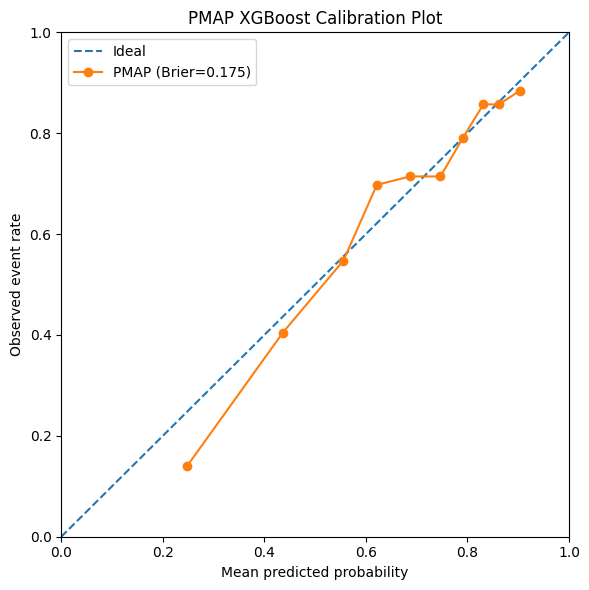

In [34]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import brier_score_loss, roc_auc_score
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

def calibration_intercept_slope(y_true, y_prob, eps=1e-6):
    """
    Compute calibration intercept and slope by regressing outcome on logit(predicted probability).
    Ideal intercept = 0, slope = 1.
    """
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_prob = np.clip(y_prob, eps, 1 - eps)

    logit_p = np.log(y_prob / (1 - y_prob))
    X = sm.add_constant(logit_p)

    fit = sm.Logit(y_true, X).fit(disp=False)

    intercept = fit.params[0]
    slope = fit.params[1]

    return intercept, slope

def calibration_metrics(y_true, y_prob):
    """
    Return a small dict of discrimination + calibration metrics.
    """
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    intercept, slope = calibration_intercept_slope(y_true, y_prob)

    return {
        "n": len(y_true),
        "event_rate": float(np.mean(y_true)),
        "auc": float(roc_auc_score(y_true, y_prob)),
        "brier": float(brier_score_loss(y_true, y_prob)),
        "calibration_intercept": float(intercept),
        "calibration_slope": float(slope),
    }

def plot_calibration_curve_one(y_true, y_prob, title="", n_bins=10, ax=None):
    """
    Reliability diagram / calibration curve.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))

    frac_pos, mean_pred = calibration_curve(
        y_true,
        y_prob,
        n_bins=n_bins,
        strategy="quantile"
    )

    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.plot(mean_pred, frac_pos, marker="o")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Observed event rate")
    ax.set_title(title)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    return ax
def plot_calibration_curve_multi(model_preds, y_true, title="", n_bins=10):
    """
    model_preds: dict like {"XGBoost": probs1, "NN": probs2, "BART": probs3}
    """
    fig, ax = plt.subplots(figsize=(6, 6))

    ax.plot([0, 1], [0, 1], linestyle="--", label="Ideal")

    for model_name, y_prob in model_preds.items():
        frac_pos, mean_pred = calibration_curve(
            y_true,
            y_prob,
            n_bins=n_bins,
            strategy="quantile"
        )
        brier = brier_score_loss(y_true, y_prob)
        ax.plot(mean_pred, frac_pos, marker="o", label=f"{model_name} (Brier={brier:.3f})")

    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Observed event rate")
    ax.set_title(title)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend()

    plt.tight_layout()
    return fig, ax

def build_calibration_table(results_dict):
    """
    results_dict structure:
    {
        ("eICU", "Neuro", "XGBoost"): (y_true, y_prob),
        ("eICU", "Neuro", "NN"): (y_true, y_prob),
        ...
    }
    """
    rows = []

    for (dataset, outcome, model), (y_true, y_prob) in results_dict.items():
        m = calibration_metrics(y_true, y_prob)
        m.update({
            "dataset": dataset,
            "outcome": outcome,
            "model": model
        })
        rows.append(m)

    df = pd.DataFrame(rows)
    df = df[
        [
            "dataset", "outcome", "model", "n", "event_rate",
            "auc", "brier", "calibration_intercept", "calibration_slope"
        ]
    ].sort_values(["dataset", "outcome", "model"]).reset_index(drop=True)

    return df
# y_pred_prob = model.predict(X_test)[:, 1]

results_dict = {
    ("eICU", "Mortality", "NN"): (y_test, y_pred_probs),
    # ...
}

calib_table = build_calibration_table(results_dict)
calib_table.round(3)
plot_calibration_curve_multi({"PMAP":y_pred_probs}, y_test, "PMAP XGBoost Calibration Plot")

In [35]:
calib_table

,dataset,outcome,model,n,event_rate,auc,brier,calibration_intercept,calibration_slope
0,eICU,Mortality,NN,424,0.660377,0.767287,0.174861,-0.133174,1.145311


In [27]:
myFeatureImportancesDf = getTopFeatures(myGridSearchCv, list(myBestModel.named_steps.covariates.get_feature_names_out()), X_train, y_train)

AttributeError: covariates

In [ ]:
myFeatureImportancesDf[myFeatureImportancesDf.Feature == 'keep__keep__bin__hypothermia']

In [25]:
myX = pd.concat([X_train.reset_index().drop(columns='index'), X_test.reset_index().drop(columns='index')])
myY = pd.concat([y_train.reset_index().drop(columns='index'), y_test.reset_index().drop(columns='index')])

Optimization terminated successfully.
         Current function value: 0.626997
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.626987
         Iterations 5
Likelihood ratio of test results:
Chi square statistic: 0.0287296788239928
p-value: 0.8654046975373156
Degress of freedom: 1.0
No interaction                            Logit Regression Results                           
Dep. Variable:         death_at_disch   No. Observations:                 1412
Model:                          Logit   Df Residuals:                     1409
Method:                           MLE   Df Model:                            2
Date:                Fri, 03 Apr 2026   Pseudo R-squ.:                 0.02184
Time:                        14:59:33   Log-Likelihood:                -885.32
converged:                       True   LL-Null:                       -905.09
Covariance Type:            nonrobust   LLR p-value:                 2.596e-09
                      

np.float64(0.8654046975373156)

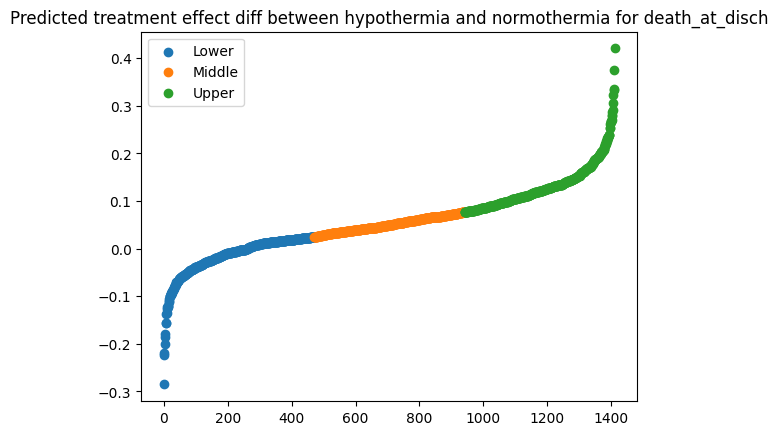

In [26]:
getTreatmentEffectDiff(aX = myX.reset_index().drop(columns='index'), aY = myY.reset_index().drop(columns='index'), aModel = myBestModel, \
                       aCategory = 'LastMGCSPositive', aGroup = 'hypothermia', aUseNeuralNetwork = False, aByGroup = False)

Optimization terminated successfully.
         Current function value: 0.627041
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.626998
         Iterations 5
Likelihood ratio of test results:
Chi square statistic: 0.12034263123678102
p-value: 0.72866317507903
Degress of freedom: 1.0
No interaction                            Logit Regression Results                           
Dep. Variable:         death_at_disch   No. Observations:                 1412
Model:                          Logit   Df Residuals:                     1409
Method:                           MLE   Df Model:                            2
Date:                Wed, 24 Dec 2025   Pseudo R-squ.:                 0.02177
Time:                        18:30:32   Log-Likelihood:                -885.38
converged:                       True   LL-Null:                       -905.09
Covariance Type:            nonrobust   LLR p-value:                 2.761e-09
                       

np.float64(0.72866317507903)

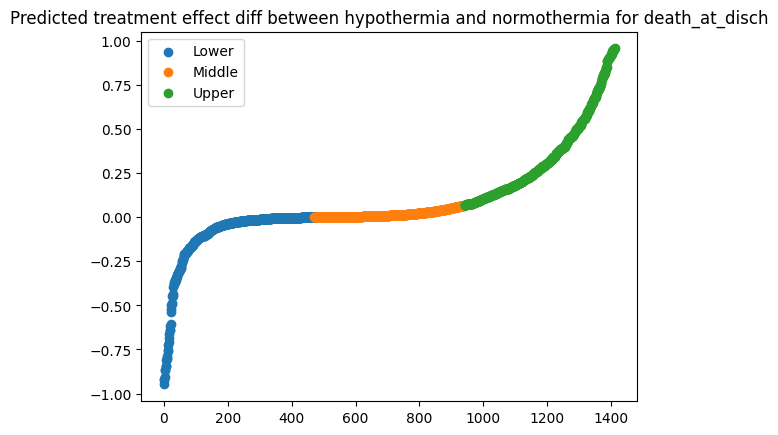

In [18]:
getTreatmentEffectDiff(aX = myX.reset_index().drop(columns='index'), aY = myY.reset_index().drop(columns='index'), aModel = myBestModel, \
                       aCategory = 'death_at_disch', aGroup = 'hypothermia', aUseNeuralNetwork = False, aByGroup = False)